<a href="https://colab.research.google.com/github/Navya-2401/Slash-Mark/blob/main/Task2_Dogs_Cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!wget -q -O cats_and_dogs.zip https://download.mlcc.google.com/mledu-datasets/cats_and_dogs_filtered.zip

!unzip -q cats_and_dogs.zip

print("Images downloaded and unzipped successfully! You are ready.")

Images downloaded and unzipped successfully! You are ready.


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    'cats_and_dogs_filtered/train',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

test_set = test_datagen.flow_from_directory(
    'cats_and_dogs_filtered/validation',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build the network
classifier = Sequential()
classifier.add(Conv2D(32, (3, 3), input_shape=(64, 64, 3), activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2, 2)))
classifier.add(Conv2D(32, (3, 3), activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2, 2)))
classifier.add(Flatten())
classifier.add(Dense(units=128, activation='relu'))
classifier.add(Dense(units=1, activation='sigmoid'))

classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting training...")
classifier.fit(train_set, epochs=5, validation_data=test_set)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.5230 - loss: 0.7059 - val_accuracy: 0.5320 - val_loss: 0.6874
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - accuracy: 0.6080 - loss: 0.6628 - val_accuracy: 0.6240 - val_loss: 0.6445
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.6795 - loss: 0.6008 - val_accuracy: 0.6590 - val_loss: 0.6081
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.7350 - loss: 0.5309 - val_accuracy: 0.6970 - val_loss: 0.5874
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 198ms/step - accuracy: 0.7855 - loss: 0.4758 - val_accuracy: 0.6880 - val_loss: 0.6195


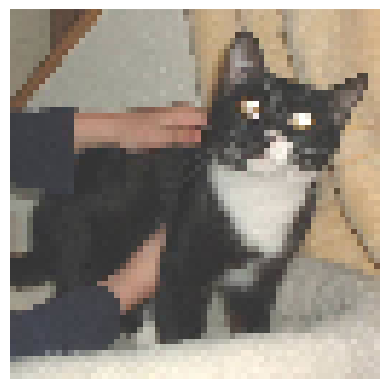

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

--- RESULTS ---
The model says: CAT! (Score: 0.30)


In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

test_image_path = 'cats_and_dogs_filtered/validation/cats/cat.2000.jpg'

test_img = image.load_img(test_image_path, target_size=(64, 64))
plt.imshow(test_img)
plt.axis('off')
plt.show()

test_img_array = image.img_to_array(test_img)
test_img_array = test_img_array / 255.0
test_img_array = np.expand_dims(test_img_array, axis=0)

result = classifier.predict(test_img_array)

print("\n--- RESULTS ---")
if result[0][0] > 0.5:
    print(f"The model says: DOG! (Score: {result[0][0]:.2f})")
else:
    print(f"The model says: CAT! (Score: {result[0][0]:.2f})")